# Cross-Country Comparison & Climate Vulnerability Ranking

Synthesize cleaned datasets from Ethiopia, Kenya, Nigeria, Sudan, and Tanzania to identify relative climate vulnerability and produce a data-driven country ranking for Ethiopia's COP32 position paper.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

## Load and Concatenate Cleaned Datasets
Load each country's cleaned CSV and combine into a single DataFrame for analysis.

In [2]:
countries = ['ethiopia', 'kenya', 'nigeria', 'sudan', 'tanzania']
dfs = []
for country in countries:
    path = f'data/{country}_clean.csv'
    if os.path.exists(path):
        df = pd.read_csv(path)
        df['Country'] = country.capitalize()
        dfs.append(df)
    else:
        print(f'Warning: {path} not found')

combined_df = pd.concat(dfs, ignore_index=True)
combined_df['DATE'] = pd.to_datetime(combined_df['DATE'])
combined_df['YEAR_INT'] = combined_df['DATE'].dt.year
combined_df['MONTH'] = combined_df['DATE'].dt.month

print('Combined dataset shape:', combined_df.shape)
print('Countries included:', combined_df['Country'].unique())
combined_df.head()

Combined dataset shape: (20540, 19)
Countries included: <StringArray>
['Ethiopia', 'Kenya', 'Nigeria', 'Sudan', 'Tanzania']
Length: 5, dtype: str


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,DATE,MONTH,outlier_flag,Country,date,Month,YEAR_INT
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,2015-01-01,1.0,False,Ethiopia,NaN,NaN,2015.0
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,2015-01-02,1.0,False,Ethiopia,NaN,NaN,2015.0
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,2015-01-03,1.0,False,Ethiopia,NaN,NaN,2015.0
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,2015-01-04,1.0,False,Ethiopia,NaN,NaN,2015.0
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,2015-01-05,1.0,False,Ethiopia,NaN,NaN,2015.0


## Temperature Trend Comparison
Plot monthly average T2M for all five countries on a single line chart (2015–2026).

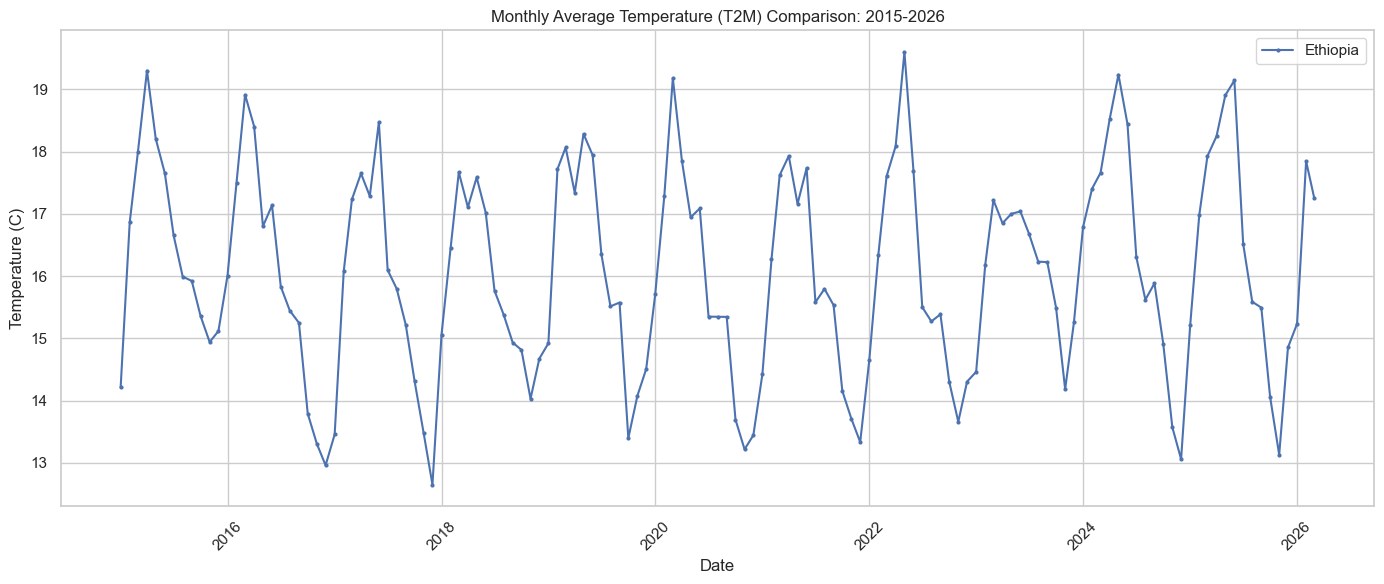

In [4]:
# Filter to 2015-2026
filtered_df = combined_df[(combined_df['YEAR_INT'] >= 2015) & (combined_df['YEAR_INT'] <= 2026)]

# Group by country and month-year for monthly averages
monthly_avg = filtered_df.groupby(['Country', 'YEAR_INT', 'MONTH'])['T2M'].mean().reset_index()
monthly_avg['Date'] = pd.to_datetime({'year': monthly_avg['YEAR_INT'], 'month': monthly_avg['MONTH'], 'day': 1})

plt.figure(figsize=(14, 6))
for country in monthly_avg['Country'].unique():
    country_data = monthly_avg[monthly_avg['Country'] == country]
    plt.plot(country_data['Date'], country_data['T2M'], label=country, marker='o', markersize=2)

plt.title('Monthly Average Temperature (T2M) Comparison: 2015-2026')
plt.xlabel('Date')
plt.ylabel('Temperature (C)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Summary Table: T2M Statistics Across Countries
Compare mean, median, and standard deviation of T2M across countries.

In [ ]:
t2m_stats = combined_df.groupby('Country')['T2M'].agg(['mean', 'median', 'std']).round(2)
t2m_stats.columns = ['Mean T2M (C)', 'Median T2M (C)', 'Std Dev T2M (C)']
t2m_stats.sort_values('Mean T2M (C)', ascending=False)